# 🚢 Training Pipeline: Baltic Handysize Freight Index (HSI) Model
### Smart India Hackathon (SIH 2024) — Vessel Chartering & Bulk Procurement
This interactive notebook trains, evaluates, and forecasts the **Baltic Handysize Index (HSI)** for 10,000–35,000 DWT vessels.


In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("All libraries imported successfully!")


All libraries imported successfully!


### 1. Load Dataset
Loading the Handysize Baltic Dry Index dataset (`dataset_used_handysize_bdi.csv`):


In [2]:
df = pd.read_csv('dataset_used_handysize_bdi.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("Date Range:", df['Date'].min().strftime('%Y-%m-%d'), "to", df['Date'].max().strftime('%Y-%m-%d'))
df.head(10)


Dataset Shape: (1749, 4)
Date Range: 2012-08-01 to 2019-07-31


,Date,HSI,DTI,CTI
0,2012-08-01,570,642,NaN
1,2012-08-02,558,638,NaN
2,2012-08-03,552,634,NaN
3,2012-08-06,544,626,NaN
4,2012-08-07,539,623,NaN
5,2012-08-08,538,619,NaN
6,2012-08-09,535,615,NaN
7,2012-08-10,531,613,NaN
8,2012-08-13,523,612,NaN
9,2012-08-14,512,608,NaN


### 2. Exploratory Data Analysis & Time Series Visualization


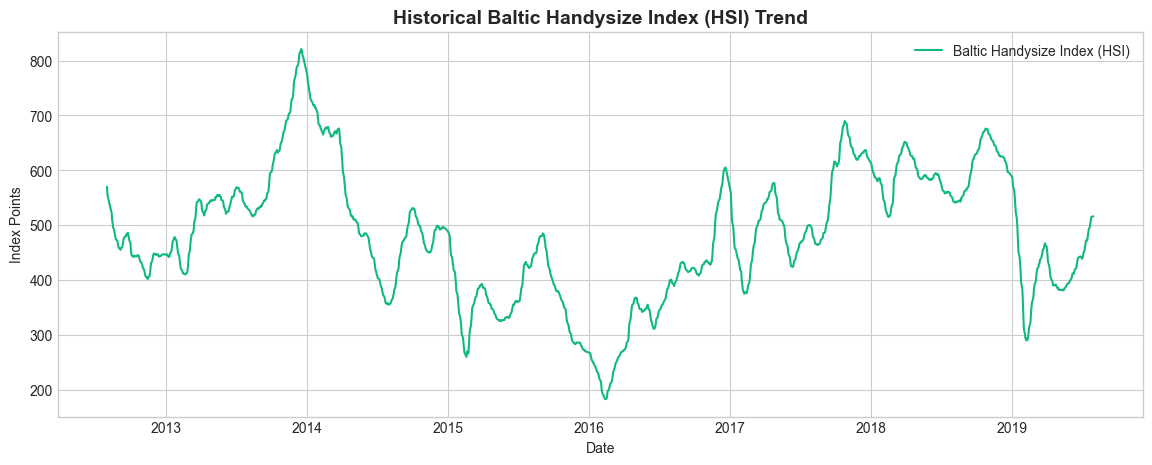

                             Date          HSI          DTI         CTI
count                        1749  1749.000000  1749.000000  903.000000
mean   2016-01-30 12:16:52.692967   480.939394   749.346484  560.617940
min           2012-08-01 00:00:00   183.000000   496.000000  346.000000
25%           2014-05-02 00:00:00   399.000000   648.000000  500.000000
50%           2016-02-02 00:00:00   475.000000   723.000000  550.000000
75%           2017-10-27 00:00:00   561.000000   822.000000  613.000000
max           2019-07-31 00:00:00   821.000000  1344.000000  919.000000
std                           NaN   119.371882   133.104285   94.511577


In [3]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['HSI'], color='#10b981', linewidth=1.5, label='Baltic Handysize Index (HSI)')
plt.title('Historical Baltic Handysize Index (HSI) Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Index Points')
plt.legend()
plt.show()

print(df.describe())


### 3. Feature Engineering (Lags, Rolling Means, Momentum)


In [4]:
# Create lag features
for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
    df[f'HSI_lag_{lag}'] = df['HSI'].shift(lag)

# Rolling statistics
for w in [7, 14, 30]:
    df[f'HSI_roll_mean_{w}'] = df['HSI'].shift(1).rolling(w).mean()
    df[f'HSI_roll_std_{w}']  = df['HSI'].shift(1).rolling(w).std()

# Calendar features
df['dayofweek'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter

# Drop NaNs created by lag windows
data = df.dropna().reset_index(drop=True)
feature_cols = [c for c in data.columns if c not in ['Date', 'HSI']]
print(f"Engineered {len(feature_cols)} features across {len(data)} trading days.")


Engineered 19 features across 903 trading days.


### 4. Time-Series Train/Test Split


In [5]:
split_idx = int(len(data) * 0.8)
train_df = data.iloc[:split_idx]
test_df = data.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df['HSI']
X_test, y_test = test_df[feature_cols], test_df['HSI']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)} samples ({train_df['Date'].min().date()} to {train_df['Date'].max().date()})")
print(f"Test size:  {len(X_test)} samples ({test_df['Date'].min().date()} to {test_df['Date'].max().date()})")


Train size: 722 samples (2015-12-16 to 2018-11-06)
Test size:  181 samples (2018-11-07 to 2019-07-31)


### 5. Train & Evaluate 4 Machine Learning Models


In [6]:
models = {
    'Ridge': Ridge(alpha=10.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, verbosity=0)
}

results = []
predictions = {'Date': test_df['Date'].values, 'Actual': y_test.values}

for name, model in models.items():
    if name == 'Ridge':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    
    predictions[name] = preds
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE (%)': mape})

results_df = pd.DataFrame(results).sort_values('MAE')
print("=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))


=== MODEL PERFORMANCE COMPARISON ===
           Model      MAE     RMSE       R2  MAPE (%)
    RandomForest 4.605774 6.716212 0.995385  1.141945
         XGBoost 5.357144 7.454848 0.994314  1.297790
GradientBoosting 5.522219 7.629104 0.994046  1.314482
           Ridge 5.698603 8.622009 0.992395  1.385874


### 6. Visualize Predictions vs Actual on Test Set


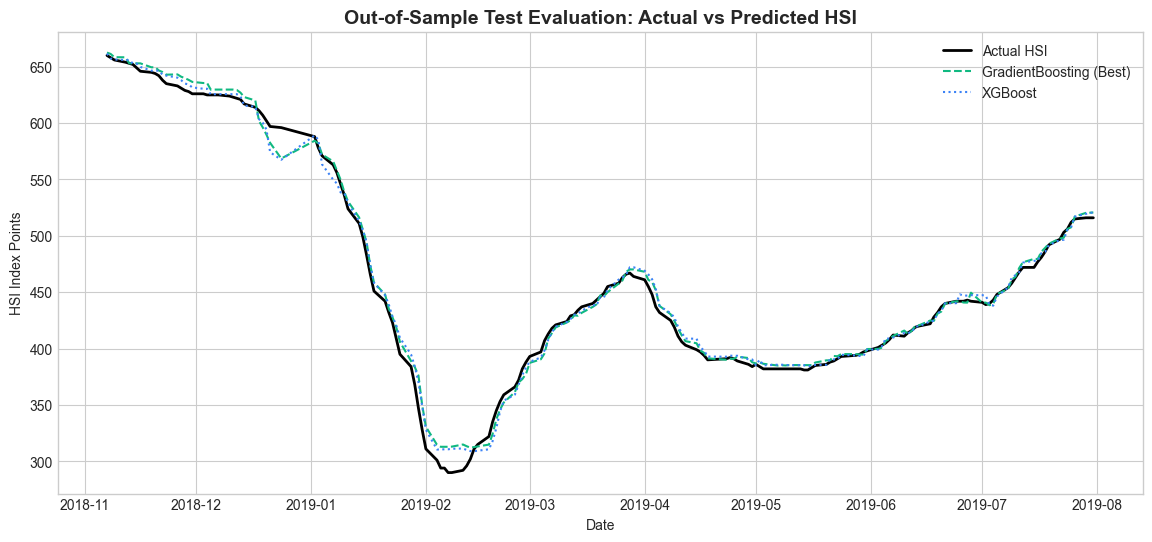

In [7]:
pred_df = pd.DataFrame(predictions)
plt.figure(figsize=(14, 6))
plt.plot(pred_df['Date'], pred_df['Actual'], label='Actual HSI', color='black', linewidth=2)
plt.plot(pred_df['Date'], pred_df['GradientBoosting'], label='GradientBoosting (Best)', color='#10b981', linestyle='--', linewidth=1.5)
plt.plot(pred_df['Date'], pred_df['XGBoost'], label='XGBoost', color='#3b82f6', linestyle=':', linewidth=1.5)
plt.title('Out-of-Sample Test Evaluation: Actual vs Predicted HSI', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('HSI Index Points')
plt.legend()
plt.show()


### 7. Save Best Model & Export Predictions


In [8]:
best_model = models['GradientBoosting']
joblib.dump(best_model, 'HSI_best_model.joblib')
pred_df.to_csv('test_predictions.csv', index=False)
print("Saved best model to 'HSI_best_model.joblib' and predictions to 'test_predictions.csv'!")


Saved best model to 'HSI_best_model.joblib' and predictions to 'test_predictions.csv'!
